<a href="https://colab.research.google.com/github/1999fello-del/steam-data-analysis-ml/blob/main/notebooks/03_ML_Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures # La herramienta para crear la curva y no una linea recta.

In [ ]:
ruta_archivo = '/content/drive/MyDrive/Mio/games_data_processed (2).csv'
df = pd.read_csv(ruta_archivo)
df.head()

,appid,name,release_date,required_age,price,dlc_count,reviews,metacritic_score,achievements,recommendations,...,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,rating_positivo,score_bruto,ratio_exito_pct,tipo_jugador,owners_media
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,NaN,0,1,4401572,...,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473,0.868255,6.022352,NaN,Multijugador,150000000.0
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,NaN,0,37,1732007,...,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720,0.592247,3.790584,NaN,Multijugador,75000000.0
2,570,Dota 2,2013-07-09,0,0.00,2,“A modern multiplayer masterpiece.” 9.5/10 – D...,90,0,14337,...,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366,0.815765,5.212436,NaN,Multijugador,350000000.0
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,NaN,96,77,1803063,...,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517,0.873088,5.462209,NaN,Multijugador,75000000.0
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,NaN,0,0,1165929,...,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608,0.840691,5.100851,NaN,Multijugador,35000000.0


In [ ]:
# 1. Convertir la columna a formato fecha
df['release_date'] = pd.to_datetime(df['release_date'])

# 2. "Amontonar" por mes y contar cuántos juegos hay
df_mensual = df.resample('MS', on='release_date').size().reset_index(name='cantidad_juegos')

# 3. CREAR LAS NUEVAS COLUMNAS
# mes_ordinal: Un número secuencial (0, 1, 2, 3...) para que el modelo entienda el paso del tiempo.
df_mensual['mes_ordinal'] = range(len(df_mensual))

# mes_del_anio: El número del mes (1 para enero, 12 para diciembre) para captar la estacionalidad.
df_mensual['mes_del_año'] = df_mensual['release_date'].dt.month

# EXTRA: anio: También ayuda mucho al modelo saber en qué año estamos.
df_mensual['año'] = df_mensual['release_date'].dt.year

# Ver el resultado
print(df_mensual.head())

  release_date  cantidad_juegos  mes_ordinal  mes_del_año   año
0   1997-06-01                1            0            6  1997
1   1997-07-01                0            1            7  1997
2   1997-08-01                0            2            8  1997
3   1997-09-01                0            3            9  1997
4   1997-10-01                0            4           10  1997


In [ ]:


# 1. PREPARACIÓN: Usamos solo datos desde 2015 para captar la era moderna
# Filtramos para que el modelo se centre en el crecimiento actual
df_moderno = df_mensual[df_mensual['año'] >= 2015].copy()

# 2. DEFINIR X e Y
X = df_moderno[['mes_ordinal']] # El tiempo es nuestra variable independiente
y = df_moderno['cantidad_juegos']

# 3. CREAR LA "CURVA" (Transformación Polinómica)
# El grado 2 permite que la línea se curve hacia arriba (aceleración)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

# 4. ENTRENAR EL MODELO
modelo_curva = LinearRegression()
modelo_curva.fit(X_poly, y)

# 5. PREDECIR EL FUTURO (Abril - Diciembre 2025)
ultimo_ordinal = df_moderno['mes_ordinal'].max()
# Creamos los índices para los próximos 9 meses
meses_futuros_idx = np.array(range(ultimo_ordinal + 1, ultimo_ordinal + 10)).reshape(-1, 1)
meses_futuros_poly = poly.transform(meses_futuros_idx)

predicciones_alza = modelo_curva.predict(meses_futuros_poly)

# Crear el DataFrame del futuro con nombres de meses para que sea legible
df_futuro = pd.DataFrame({
    'Fecha': pd.date_range(start='2025-04-01', periods=9, freq='MS'),
    'Estimacion_Juegos': predicciones_alza.round(0).astype(int),
    'Estado': 'Predicción'
})

# Añadimos una columna con el nombre del mes
df_futuro['Mes'] = df_futuro['Fecha'].dt.month_name()

# 6. MOSTRAR RESULTADOS DETALLADOS
print("--- ESTIMACIONES DETALLADAS PARA 2025 (ABRIL A DICIEMBRE) ---")
print(df_futuro[['Mes', 'Fecha', 'Estimacion_Juegos']])

# 7. COMPARATIVA DE TOTALES
total_2024 = 17364
# Sumamos los reales que ya tienes (Ene-Mar) más los nuevos que acabamos de predecir
# Nota: Asegúrate de que df_mensual tenga los datos de Ene-Mar 2025
total_2025_real_ene_mar = df_mensual[df_mensual['año'] == 2025]['cantidad_juegos'].sum()
total_2025_estimado_final = total_2025_real_ene_mar + df_futuro['Estimacion_Juegos'].sum()

print("\n--- RESUMEN ANUAL ---")
print(f"Total juegos 2024: {total_2024}")
print(f"Total ESTIMADO 2025: {total_2025_estimado_final}")

--- ESTIMACIONES DETALLADAS PARA 2025 (ABRIL A DICIEMBRE) ---
         Mes      Fecha  Estimacion_Juegos
0      April 2025-04-01               1611
1        May 2025-05-01               1650
2       June 2025-06-01               1690
3       July 2025-07-01               1731
4     August 2025-08-01               1772
5  September 2025-09-01               1815
6    October 2025-10-01               1859
7   November 2025-11-01               1904
8   December 2025-12-01               1950

--- RESUMEN ANUAL ---
Total juegos 2024: 17364
Total ESTIMADO 2025: 19404


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


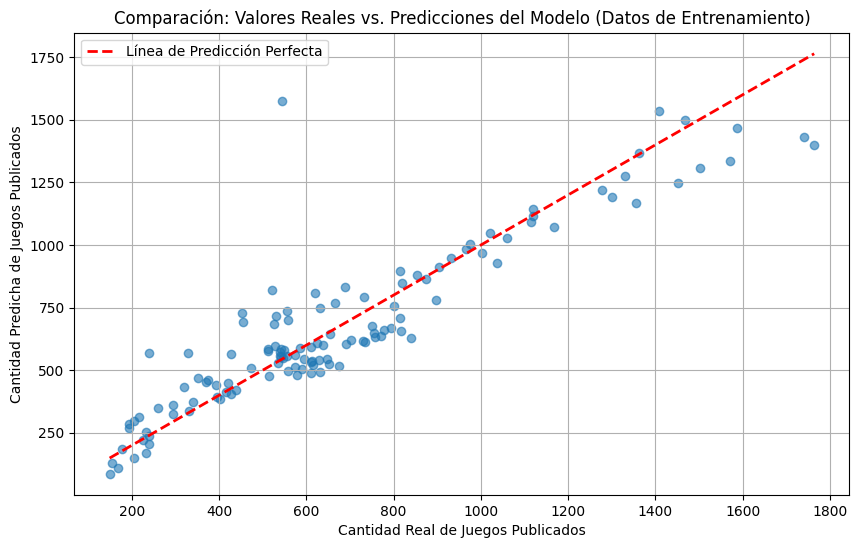

In [ ]:
import matplotlib.pyplot as plt

# Generar predicciones para los datos de entrenamiento
predicciones_entrenamiento = modelo_curva.predict(X_poly)

# Crear el scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y, predicciones_entrenamiento, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Línea de Predicción Perfecta')
plt.title('Comparación: Valores Reales vs. Predicciones del Modelo (Datos de Entrenamiento)')
plt.xlabel('Cantidad Real de Juegos Publicados')
plt.ylabel('Cantidad Predicha de Juegos Publicados')
plt.grid(True)
plt.legend()
plt.show()

Este gráfico de dispersión muestra qué tan cerca están las predicciones de su modelo de los valores reales en los datos de entrenamiento. Cuanto más cerca estén los puntos de la línea roja (que representa una predicción perfecta), mejor será el rendimiento del modelo.

In [ ]:
from google.colab import files

# Guardamos el DataFrame de las predicciones en un archivo CSV
df_futuro.to_csv('predicciones_abril_diciembre_2025.csv', index=False, encoding='utf-8-sig')

# files.download('predicciones_abril_diciembre_2025.csv')

print("El archivo con las estimaciones de 2025 se está descargando...")

El archivo con las estimaciones de 2025 se está descargando...
